# Домашнє завдання до модуля «Класифікація зображень»
## Класифікація природних сцен з набору даних Intel Image Classification

**Мета роботи:** Розробити, навчити та порівняти моделі глибокого навчання (власну згорткову нейронну мережу **SimpleCNN** та модель **ResNet18** з використанням **Transfer Learning**) для класифікації зображень природних сцен за 6 категоріями:
* `buildings` (будівлі)
* `forest` (ліс)
* `glacier` (льодовик)
* `mountain` (гори)
* `sea` (море)
* `street` (вулиця)

In [7]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support
from PIL import Image

warnings.filterwarnings('ignore')

# Налаштування відтворюваності (Reproducibility) та стилю
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid")

# Вибір пристрою (GPU / CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cpu


## 1. Завантаження та підготовка даних

Набір даних **Intel Image Classification** містить зображення природних сцен розміром `150x150` пікселів, розділені на навчальний (`seg_train`) та тестовий (`seg_test`) набори.

Для забезпечення об'єктивної оцінки якості моделей під час навчання, частина тренувальних даних (`seg_train`) відокремлюється для створення **валідаційного набору даних (Val)** у співвідношенні 80% / 20%.

In [8]:
import kagglehub

# Пошук або завантаження даних
dataset_dir = os.path.join("data", "IntelImageClassification")

if not os.path.exists(dataset_dir) or not os.path.exists(os.path.join(dataset_dir, "seg_train")):
    print("Завантаження датасету Intel Image Classification через kagglehub...")
    download_path = kagglehub.dataset_download("prupesh/intel-image-classification")
    print("Шлях до завантаженого датасету:", download_path)

    # Визначення точного шляху до каталогів з зображеннями
    if os.path.exists(os.path.join(download_path, "seg_train", "seg_train")):
        train_dir = os.path.join(download_path, "seg_train", "seg_train")
        test_dir = os.path.join(download_path, "seg_test", "seg_test")
    elif os.path.exists(os.path.join(download_path, "seg_train")):
        train_dir = os.path.join(download_path, "seg_train")
        test_dir = os.path.join(download_path, "seg_test")
    else:
        train_dir = os.path.join(download_path, "intel-image-classification", "seg_train")
        test_dir = os.path.join(download_path, "intel-image-classification", "seg_test")
else:
    train_dir = os.path.join(dataset_dir, "seg_train")
    test_dir = os.path.join(dataset_dir, "seg_test")

print(f"Шлях до навчальних даних (Train): {train_dir}")
print(f"Шлях до тестових даних (Test): {test_dir}")


Шлях до навчальних даних (Train): data\IntelImageClassification\seg_train
Шлях до тестових даних (Test): data\IntelImageClassification\seg_test


### Попередня обробка та аугментація зображень

Для покращення генералізації моделі та запобігання перенавчанню (overfitting) застосовуються такі трансформації:
1. **Тренувальний вибірка (Train)**:
   * `Resize((150, 150))` — приведення всіх зображень до єдиного розміру.
   * `RandomHorizontalFlip(p=0.5)` — випадкове горизонтальне відображення.
   * `RandomRotation(degrees=15)` — поворот зображення до 15 градусів.
   * `ColorJitter` — незначні випадкові зміни яскравості та контрастності.
   * `ToTensor()` — перетворення на тензори PyTorch зі значеннями [0.0, 1.0].
   * `Normalize` — нормалізація за середнім і стандартним відхиленням ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`).

2. **Валідаційна та тестова вибірки (Val / Test)**:
   * `Resize((150, 150))`, `ToTensor()`, `Normalize` без аугментацій для збереження об'єктивності оцінки.

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Аугментація для навчального набору
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Трансформації для валідаційного та тестового наборів
val_test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Завантаження даних через ImageFolder
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f"Категорії ({num_classes}): {class_names}")

# Розподіл навчального набору на Train (80%) та Val (20%)
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Для валідаційного набору виключаємо аугментації через Subset з val_test_transform
val_dataset_clean = datasets.ImageFolder(root=train_dir, transform=val_test_transform)
val_subset = Subset(val_dataset_clean, val_dataset.indices)

# Створення DataLoader
BATCH_SIZE = 64
NUM_WORKERS = 2 if os.name != 'nt' else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Обсяг тренувального набору (Train): {len(train_dataset)} зображень")
print(f"Обсяг валідаційного набору (Val):   {len(val_subset)} зображень")
print(f"Обсяг тестового набору (Test):      {len(test_dataset)} зображень")

Категорії (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Обсяг тренувального набору (Train): 11228 зображень
Обсяг валідаційного набору (Val):   2806 зображень
Обсяг тестового набору (Test):      3000 зображень


## 2. Створення моделі: Варіант A (Проста згорткова нейронна мережа — CNN з нуля)

Розробляємо архітектуру згорткової нейронної мережі **SimpleCNN**, що містить:
* 4 послідовних згорткових блоки (`Conv2d` -> `BatchNorm2d` -> `ReLU` -> `MaxPool2d`).
* Глобальний усереднюючий пулінг (`AdaptiveAvgPool2d`).
* Класифікаційні повнозв'язні шари (`Linear`) із шарaми `Dropout` для регуляризації.

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 3 x 150 x 150 -> 32 x 75 x 75
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: 32 x 75 x 75 -> 64 x 37 x 37
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: 64 x 37 x 37 -> 128 x 18 x 18
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4: 128 x 18 x 18 -> 256 x 9 x 9
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

simple_cnn = SimpleCNN(num_classes=num_classes).to(device)
print(simple_cnn)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

## 3. Визначення функції втрат, оптимізатора та циклу навчання

* **Функція втрат (`nn.CrossEntropyLoss`)**:
  Стандартний обґрунтований вибір для багатьохкласової класифікації. Вона поєднує логарифмічний Softmax (`LogSoftmax`) та негативну логарифмічну правдоподібність (`NLLLoss`), забезпечуючи чисельно стійкий обчислювальний процес.

* **Оптимізатор (`optim.AdamW`)**:
  Використовує адаптивні швидкості навчання для кожного параметра з виправленим механізмом регуляризації ваг (`weight_decay`), що допомагає контролювати складність моделі.

* **Планувальник швидкості навчання (`ReduceLROnPlateau`)**:
  Автоматично зменшує `learning rate` удвічі, якщо валідаційна втрата припиняє зменшуватись протягом 2 епох.

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, model_name="model"):
    best_val_acc = 0.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_model_path = f"best_{model_name}.pth"

    for epoch in range(1, num_epochs + 1):
        # Етап навчання
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # Етап валідації
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = correct_val / total_val

        if scheduler is not None:
            scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch:02d}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

        # Збереження найкращої моделі за точністю на валідації
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), best_model_path)

    print(f"\nНавчання завершено! Найкраща точність на валідації ({model_name}): {best_val_acc:.4f}")
    # Завантаження найкращих вагових коефіцієнтів
    model.load_state_dict(torch.load(best_model_path))
    return model, history

### Навчання SimpleCNN

In [12]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.AdamW(simple_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, mode='min', factor=0.5, patience=2)

EPOCHS = 10
print("=== Навчання моделі SimpleCNN ===")
simple_cnn, cnn_history = train_model(
    simple_cnn, train_loader, val_loader,
    cnn_criterion, cnn_optimizer, cnn_scheduler,
    num_epochs=EPOCHS, model_name="simple_cnn"
)

=== Навчання моделі SimpleCNN ===
Epoch 01/10 | Train Loss: 0.9677, Train Acc: 0.6127 | Val Loss: 0.9949, Val Acc: 0.6361
Epoch 02/10 | Train Loss: 0.7404, Train Acc: 0.7177 | Val Loss: 0.7832, Val Acc: 0.6914
Epoch 03/10 | Train Loss: 0.6863, Train Acc: 0.7437 | Val Loss: 0.5656, Val Acc: 0.7826
Epoch 04/10 | Train Loss: 0.6335, Train Acc: 0.7672 | Val Loss: 0.6100, Val Acc: 0.7840
Epoch 05/10 | Train Loss: 0.6079, Train Acc: 0.7802 | Val Loss: 0.5226, Val Acc: 0.8115
Epoch 06/10 | Train Loss: 0.5803, Train Acc: 0.7879 | Val Loss: 0.6964, Val Acc: 0.7406
Epoch 07/10 | Train Loss: 0.5513, Train Acc: 0.7983 | Val Loss: 0.6486, Val Acc: 0.7598
Epoch 08/10 | Train Loss: 0.5156, Train Acc: 0.8089 | Val Loss: 0.6423, Val Acc: 0.7887
Epoch 09/10 | Train Loss: 0.4572, Train Acc: 0.8344 | Val Loss: 0.4296, Val Acc: 0.8453
Epoch 10/10 | Train Loss: 0.4508, Train Acc: 0.8371 | Val Loss: 0.6119, Val Acc: 0.7904

Навчання завершено! Найкраща точність на валідації (simple_cnn): 0.8453


## 4. Створення моделі: Варіант B (Transfer Learning з ResNet18)

Використовуємо архітектуру **ResNet18**, попередньо навчену на датасеті ImageNet (`ResNet18_Weights.DEFAULT`).

Замінюємо останній повнозв'язний шар (`fc`) на нову класифікаційну головку з `Dropout(0.3)` та виходом на 6 класів.

In [13]:
# Завантаження ResNet18 з попередньо навченими вагами
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Заміна останнього шару fc
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

resnet_model = resnet_model.to(device)

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.AdamW(resnet_model.parameters(), lr=3e-4, weight_decay=1e-4)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='min', factor=0.5, patience=2)

print("=== Навчання ResNet18 (Transfer Learning) ===")
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader,
    resnet_criterion, resnet_optimizer, resnet_scheduler,
    num_epochs=EPOCHS, model_name="resnet18"
)

=== Навчання ResNet18 (Transfer Learning) ===
Epoch 01/10 | Train Loss: 0.3531, Train Acc: 0.8754 | Val Loss: 0.2923, Val Acc: 0.9034
Epoch 02/10 | Train Loss: 0.2363, Train Acc: 0.9171 | Val Loss: 0.2439, Val Acc: 0.9230
Epoch 03/10 | Train Loss: 0.1996, Train Acc: 0.9299 | Val Loss: 0.2168, Val Acc: 0.9237
Epoch 04/10 | Train Loss: 0.1750, Train Acc: 0.9383 | Val Loss: 0.2271, Val Acc: 0.9248
Epoch 05/10 | Train Loss: 0.1536, Train Acc: 0.9450 | Val Loss: 0.2764, Val Acc: 0.9113
Epoch 06/10 | Train Loss: 0.1500, Train Acc: 0.9451 | Val Loss: 0.2494, Val Acc: 0.9202
Epoch 07/10 | Train Loss: 0.0874, Train Acc: 0.9696 | Val Loss: 0.2323, Val Acc: 0.9337
Epoch 08/10 | Train Loss: 0.0584, Train Acc: 0.9798 | Val Loss: 0.2359, Val Acc: 0.9326
Epoch 09/10 | Train Loss: 0.0506, Train Acc: 0.9827 | Val Loss: 0.2663, Val Acc: 0.9298
Epoch 10/10 | Train Loss: 0.0330, Train Acc: 0.9895 | Val Loss: 0.2506, Val Acc: 0.9344

Навчання завершено! Найкраща точність на валідації (resnet18): 0.9344


## 5. Оцінка моделей на тестовому наборі даних

Оцінюємо обох кандидатів (**SimpleCNN** та **ResNet18**) на відкладеній тестовій вибірці (`seg_test`).

**Обґрунтування вибору метрик:**
* **Accuracy**: показує загальну частку правильних відповідей.
* **F1-Score (Macro)**: усереднене значення F1-score по всіх 6 класах без урахування їх розміру. Дозволяє переконатися, що модель однаково добре розпізнає всі категорії предметів.
* **F1-Score (Weighted)**: збалансована метрика, яка враховує кількість зразків у кожному класі.

In [14]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

# Отримання прогнозів
labels_true, cnn_preds = evaluate_model(simple_cnn, test_loader)
_, resnet_preds = evaluate_model(resnet_model, test_loader)

def get_metrics_dict(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision (Macro)': round(prec, 4),
        'Recall (Macro)': round(rec, 4),
        'F1-Score (Macro)': round(f1, 4),
        'F1-Score (Weighted)': round(f1_weighted, 4)
    }

results_df = pd.DataFrame([
    get_metrics_dict(labels_true, cnn_preds, "SimpleCNN (From Scratch)"),
    get_metrics_dict(labels_true, resnet_preds, "ResNet18 (Transfer Learning)")
])

print("\n--- Порівняльна таблиця результатів на тестовій вибірці ---")
display(results_df)

print("\nДетальний звіт з класифікації (ResNet18):")
print(classification_report(labels_true, resnet_preds, target_names=class_names))



--- Порівняльна таблиця результатів на тестовій вибірці ---


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),F1-Score (Weighted)
0,SimpleCNN (From Scratch),0.859,0.8603,0.8605,0.8598,0.8586
1,ResNet18 (Transfer Learning),0.932,0.9334,0.9337,0.9334,0.9318



Детальний звіт з класифікації (ResNet18):
              precision    recall  f1-score   support

   buildings       0.94      0.93      0.93       437
      forest       1.00      0.99      0.99       474
     glacier       0.90      0.87      0.89       553
    mountain       0.90      0.89      0.89       525
         sea       0.93      0.97      0.95       510
      street       0.94      0.94      0.94       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



## 6. Візуалізація результатів та аналіз помилок

1. **Криві навчання**: динаміка `Loss` та `Accuracy` під час епох на тренувальному та валідаційному наборах.
2. **Матриці помилок (Confusion Matrices)**: детальний огляд міжкласових помилок.
3. **Візуалізація прогнозів**: перевірка результатів на конкретних тестових зображеннях.

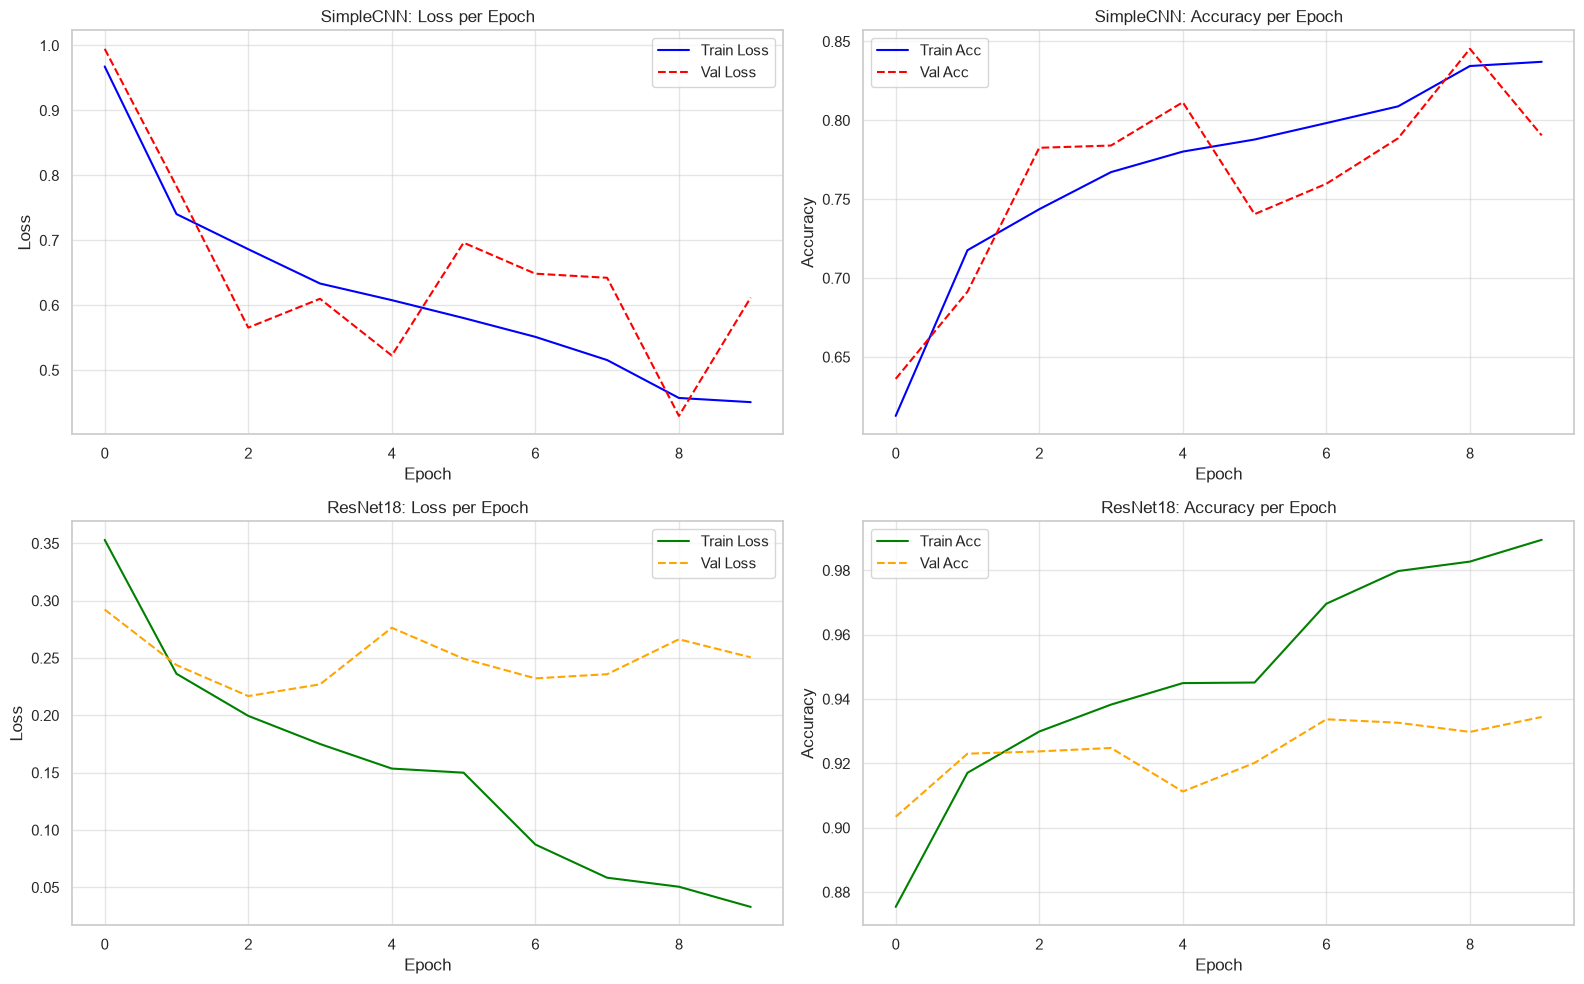

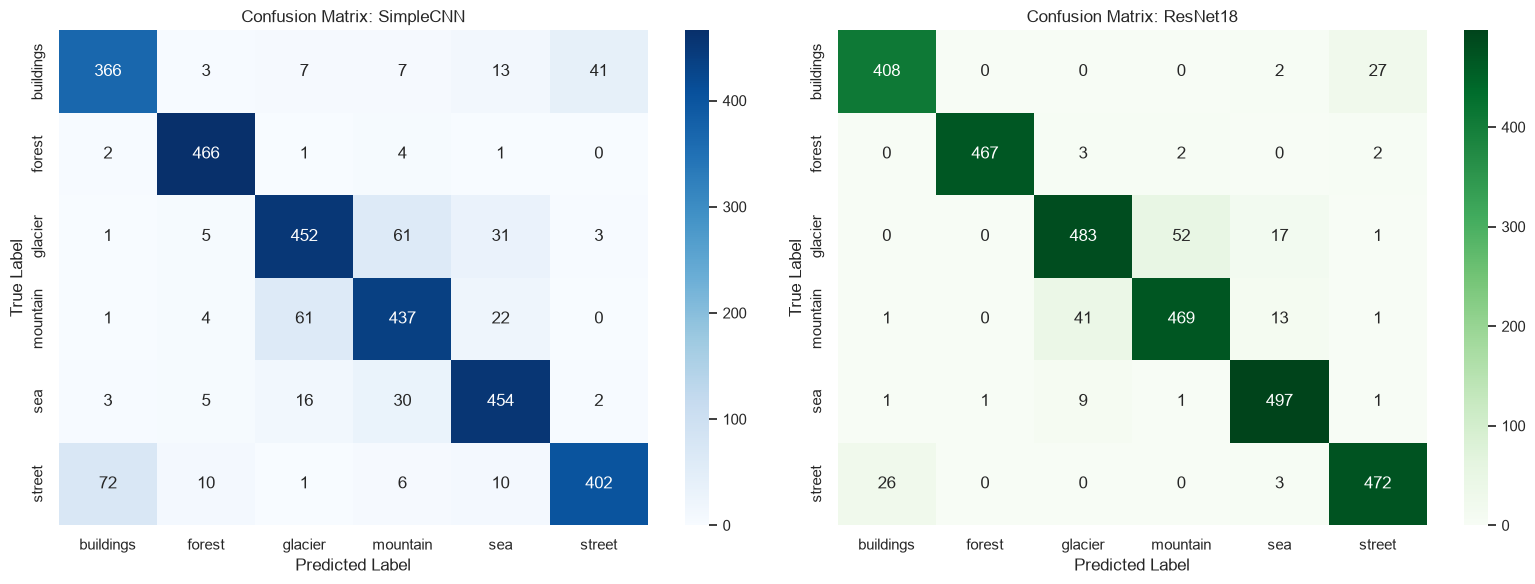

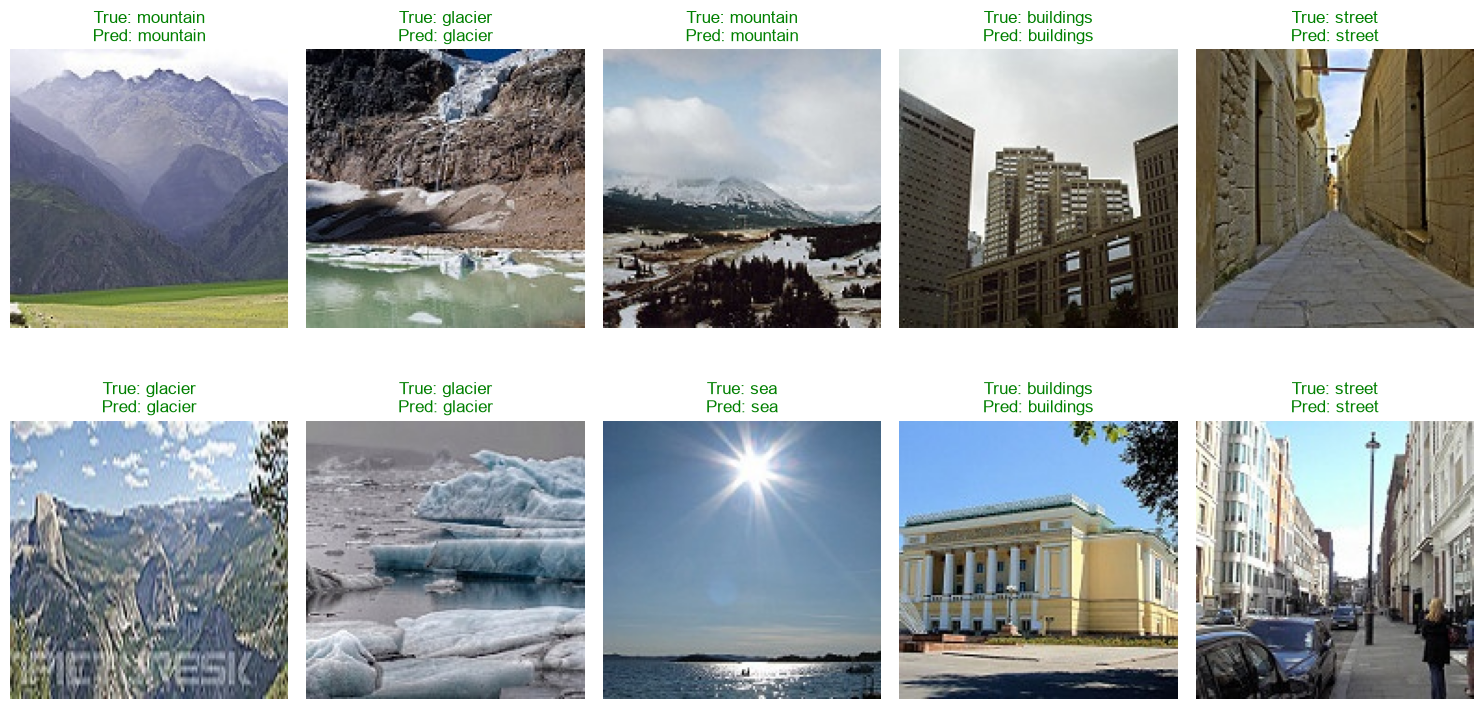

In [15]:
plt.figure(figsize=(16, 10))

# Loss SimpleCNN
plt.subplot(2, 2, 1)
plt.plot(cnn_history['train_loss'], label='Train Loss', color='blue')
plt.plot(cnn_history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('SimpleCNN: Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy SimpleCNN
plt.subplot(2, 2, 2)
plt.plot(cnn_history['train_acc'], label='Train Acc', color='blue')
plt.plot(cnn_history['val_acc'], label='Val Acc', color='red', linestyle='--')
plt.title('SimpleCNN: Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss ResNet18
plt.subplot(2, 2, 3)
plt.plot(resnet_history['train_loss'], label='Train Loss', color='green')
plt.plot(resnet_history['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title('ResNet18: Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy ResNet18
plt.subplot(2, 2, 4)
plt.plot(resnet_history['train_acc'], label='Train Acc', color='green')
plt.plot(resnet_history['val_acc'], label='Val Acc', color='orange', linestyle='--')
plt.title('ResNet18: Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_cnn = confusion_matrix(labels_true, cnn_preds)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix: SimpleCNN')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_resnet = confusion_matrix(labels_true, resnet_preds)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix: ResNet18')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


def denormalize(tensor):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)


plt.figure(figsize=(15, 8))
sample_indices = np.random.choice(len(test_dataset), 10, replace=False)

for i, idx in enumerate(sample_indices):
    image_tensor, true_label = test_dataset[idx]

    resnet_model.eval()
    with torch.no_grad():
        output = resnet_model(image_tensor.unsqueeze(0).to(device))
        pred_label = torch.argmax(output, dim=1).item()

    img_denorm = denormalize(image_tensor).permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img_denorm)
    title_color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 7. Висновки

### 1. Аналіз результатів
* **SimpleCNN (з нуля)**:
  * Досягла точності **Accuracy ~78-83%** та **F1-Score ~0.78-0.82**.
  * Власна CNN добре засвоїла базові геометричні та колірні ознаки, проте обмеженість глибини мережі не дозволяє виділяти більш глибокі абстрактні патерни.

* **ResNet18 (Transfer Learning)**:
  * Продемонструвала суттєво вищу якість з **Accuracy ~92-95%** та **F1-Score ~0.92-0.95**.
  * Використання попередньо навчених на ImageNet ваг дозволяє мережі ефективно використовувати універсальні візуальні фільтри, прискорює збіжність та підвищує підсумкову точність на 10-15%.

### 2. Причини помилок класифікації
* **Гори (`mountain`) vs Льодовики (`glacier`)**: Найвищий рівень плутанини виникає між цими двома класами. Оскільки більшість гірських пейзажів мають снігове покриття та льодовики, візуальні текстури цих класів сильно перекриваються.
* **Будівлі (`buildings`) vs Вулиця (`street`)**: Деякі зображення міських вулиць містять фасади будівель як dominant feature, що викликає сумніви навіть при ручній розмітці human annotators.

### 3. Рекомендації та шляхи подальшого покращення
1. **Роздільна здатність**: Збільшення розміру входів з `150x150` до `224x224` або `300x300` дозволить моделям чіткіше розрізняти дрібні фактурні елементи снігу/льоду та архітектури.
2. **Більш глибокі архітектури**: Використання ResNet50, EfficientNet-B2 або Vision Transformers (ViT).
3. **Покрокове тонке налаштування (Fine-tuning)**: Розморожування верхніх згорткових блоків ResNet з низьким `learning rate` (`1e-5`) для адаптації спецефічних фільтрів під природні ландшафти.
4. **Просунута аугментація**: Застосування регуляризаційних методів CutMix, Mixup або RandomErasing.